In [1]:
import pandas as pd
import numpy as np

In [2]:
filename = '../data/vindr-full/data/finding_annotations.csv'
df = pd.read_csv(filename)
print(df.shape)
df.columns

(20486, 16)


Index(['study_id', 'series_id', 'image_id', 'laterality', 'view_position',
       'height', 'width', 'breast_birads', 'breast_density',
       'finding_categories', 'finding_birads', 'xmin', 'ymin', 'xmax', 'ymax',
       'split'],
      dtype='str')

In [19]:
# Detect rows with 'No Finding' (handles string lists like "['No Finding']" or "['Nipple Retraction', 'Mass']")
df['has_no_finding'] = df['finding_categories'].astype(str).str.contains(r'No Finding', case=False, na=False)

# Find study_ids where EVERY row for that study_id has 'No Finding'
study_ids_no_finding = (
    df.groupby('study_id')['has_no_finding']
    .agg(all_have_no_finding='all')
    .query('all_have_no_finding')
    .index
    .tolist()
)

print(f"Found {len(study_ids_no_finding)} study_ids where ALL rows are 'No Finding'.")

# Filter the full original rows for these study_ids only
df_no_finding_full = df[df['study_id'].isin(study_ids_no_finding)].copy()
df_no_finding_full = df_no_finding_full.drop(columns=['has_no_finding'])

# Save to a new CSV with ALL original columns (full rows)
df_no_finding_full.to_csv('../data/vindr/no_findings.csv', index=False)

print(f"Saved {len(df_no_finding_full)} full rows to 'no_finding_full_rows.csv'")
print(f"These rows belong to the {len(study_ids_no_finding)} normal (no-finding) studies.")

# quick summary
# print("\nSummary of saved data:")
# print(df_no_finding_full['split'].value_counts())
# print(df_no_finding_full[['study_id', 'series_id', 'image_id']].nunique())


Found 4076 study_ids where ALL rows are 'No Finding'.
Saved 16304 full rows to 'no_finding_full_rows.csv'
These rows belong to the 4076 normal (no-finding) studies.


In [ ]:
import cv2
import numpy as np
import pydicom
from pydicom.pixels import apply_voi_lut, apply_windowing

def _resize_with_pad(img: np.ndarray, size: int) -> np.ndarray:
    """Scale image to fit inside (size x size), pad right/bottom with zeros."""
    h, w = img.shape
    scale = size / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)
    img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.zeros((size, size), dtype=np.uint8)
    pad_y = (size - new_h) // 2
    canvas[pad_y : pad_y + new_h, :new_w] = img
    return canvas


def _crop_breast(img: np.ndarray) -> np.ndarray:
    """Remove background and crop to the breast bounding box."""
    _, thresh = cv2.threshold(img, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    return img[y : y + h, x : x + w]


def load_mammogram(path: str, size: int = 512, flip: bool = False) -> np.ndarray:
    """Read a DICOM mammography file, remove background, crop breast, resize.

    Steps:
      1. Read pixel array and apply VOI LUT (window/level or LUT table)
      2. Invert MONOCHROME1 images so tissue is always bright
      3. Normalize to uint8
      4. Remove black background and crop to breast bounding box
      5. Optionally flip horizontally (e.g. to normalise right breasts to face left)
      6. Scale to fit (size x size) preserving aspect ratio, pad remainder with zeros

    Args:
        path: Path to a .dicom / .dcm file.
        size: Output side length in pixels (default 512).
        flip: If True, flip the image horizontally before resizing.

    Returns:
        uint8 numpy array of shape (size, size).
    """
    ds = pydicom.dcmread(path)
    pixels = ds.pixel_array  # keep integer dtype for apply_voi_lut

    # Apply VOI LUT: uses LUT table if present, falls back to WindowCenter/Width
    img = apply_voi_lut(pixels, ds).astype(np.float32)
    # img = apply_windowing(pixels, ds).astype(np.float32)

    # MONOCHROME1: 0 = white (air), max = black (tissue) — invert to MONOCHROME2 convention
    if ds.PhotometricInterpretation == "MONOCHROME1":
        img = img.max() - img

    # Normalize to [0, 255]
    lo, hi = img.min(), img.max()
    if hi > lo:
        img = (img - lo) / (hi - lo) * 255.0
    img = img.astype(np.uint8)

    img = _crop_breast(img)
    if flip:
        img = cv2.flip(img, 1)
    img = _resize_with_pad(img, size)
    return img




VOI LUT exists
VOI LUT exists


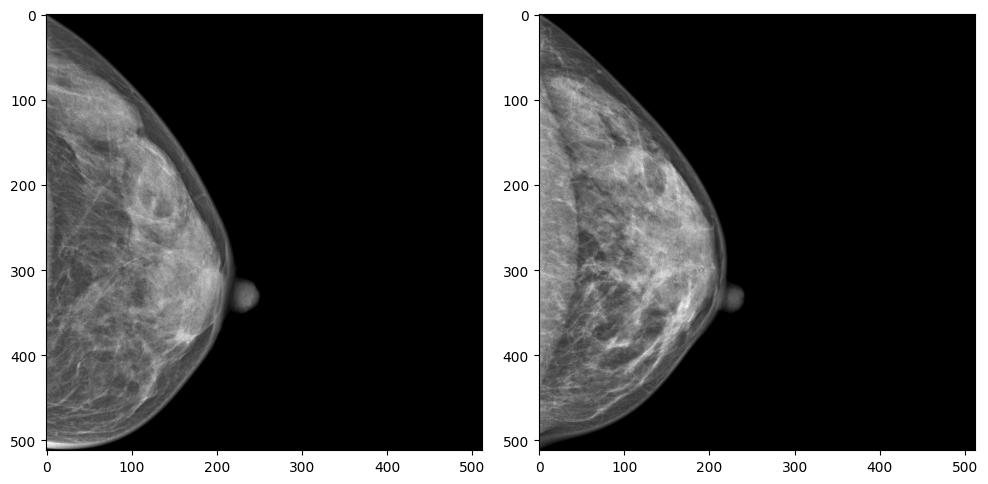

In [7]:
import matplotlib.pyplot as plt

img_l = load_mammogram('/mnt/c/research/datasets/vindr-full/data/images/0025a5dc99fd5c742026f0b2b030d3e9/451562831387e2822923204cf8f0873e.dcm')
img_r = load_mammogram('/mnt/c/research/datasets/vindr-full/data/images/0025a5dc99fd5c742026f0b2b030d3e9/fcf12c2803ba8dc564bf1287c0c97d9a.dcm',flip=True)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_l, cmap='gray')
axs[1].imshow(img_r, cmap='gray')

plt.tight_layout()
plt.show()
